<a href="https://colab.research.google.com/github/caviteri/Ciencia-de-Datos-2026/blob/main/Ciencia_de_Datos_Semana_08_Inferencia_Bayesiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

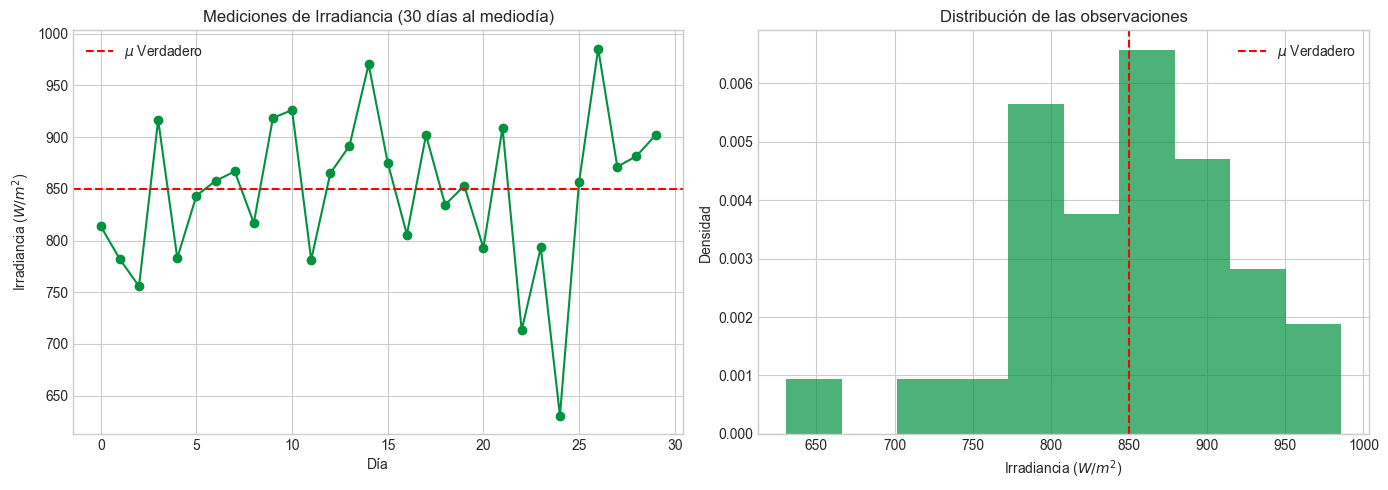

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Configuración estética de las gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


# 1. GENERACIÓN DE DATOS SINTÉTICOS
#np.random.seed(42) # Para reproducibilidad en clase

# Parámetros "Verdaderos" (Desconocidos para el estimador)
mu_true = 850.0    # Irradiancia media real en W/m^2
sigma_true = 75.0  # Desviación estándar (ruido/clima)

# Simulamos 30 días de mediciones independientes (n=30)
n_samples = 30
mediciones = np.random.normal(loc=mu_true, scale=sigma_true, size=n_samples)

# Visualización de los datos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de serie de tiempo
ax1.plot(mediciones, marker='o', linestyle='-', color='#00923F') # Usando verde Udenar
ax1.axhline(mu_true, color='red', linestyle='--', label=r'$\mu$ Verdadero')
ax1.set_title('Mediciones de Irradiancia (30 días al mediodía)')
ax1.set_xlabel('Día')
ax1.set_ylabel('Irradiancia ($W/m^2$)')
ax1.legend()

# Histograma
ax2.hist(mediciones, bins=10, density=True, alpha=0.7, color='#00923F')
ax2.axvline(mu_true, color='red', linestyle='--', label=r'$\mu$ Verdadero')
ax2.set_title('Distribución de las observaciones')
ax2.set_xlabel('Irradiancia ($W/m^2$)')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.tight_layout()
plt.show()

## Parte 3: Inferencia Bayesiana - Incorporando Conocimiento Previo

En la inferencia Bayesiana, los parámetros que queremos estimar se tratan como **variables aleatorias**. Antes de ver cualquier dato, tenemos una creencia sobre los posibles valores del parámetro, representada por la **distribución a priori** (o *prior*), $f_\Theta(\theta)$.

El Teorema de Bayes nos permite actualizar esta creencia una vez observamos los datos $X=x$, obteniendo la **distribución a posteriori**, $f_{\Theta|X}(\theta|x)$:

$$f_{\Theta|X}(\theta|x) = \frac{f_{X|\Theta}(x|\theta)f_\Theta(\theta)}{f_X(x)} \propto \text{Verosimilitud} \times \text{Prior}$$

**Nuestro escenario:**
Supongamos que el fabricante del panel solar y los datos satelitales históricos nos dicen que, en esta época del año en Pasto, la irradiancia al mediodía suele estar alrededor de $900 \: W/m^2$. Modelaremos este conocimiento previo como una distribución Gaussiana:
$$\mu \sim \mathcal{N}(\mu_{prior}, \sigma_{prior}^2)$$

In [2]:
import scipy.stats as stats

sigma_mle = 67.7

# 1. DEFINICIÓN DEL CONOCIMIENTO PREVIO (PRIOR)
mu_prior = 900.0      # Creencia inicial sobre la media
sigma_prior = 15.0    # Incertidumbre de nuestra creencia inicial

print(f"Prior: N(mu={mu_prior}, sigma={sigma_prior})")

Prior: N(mu=900.0, sigma=15.0)


### 3.1 Solución Analítica (Priores Conjugados)

Para simplificar, asumiremos que la varianza del ruido de las mediciones $\sigma^2$ es conocida (usaremos nuestro estimado anterior `sigma_mle`).

Cuando la Verosimilitud es Gaussiana y el *Prior* también es Gaussiano, la matemática se simplifica. Se dice que la Gaussiana es el **prior conjugado** de la media de otra Gaussiana. Esto significa que la **Posteriori también será una distribución Gaussiana**.

Las fórmulas para la media y varianza de la posteriori son:

1. **Varianza a posteriori:** $$\sigma_{post}^2 = \left( \frac{1}{\sigma_{prior}^2} + \frac{n}{\sigma^2} \right)^{-1}$$

2. **Media a posteriori (Estimador MAP y MMSE):**
   $$\mu_{post} = \sigma_{post}^2 \left( \frac{\mu_{prior}}{\sigma_{prior}^2} + \frac{n \cdot \bar{x}}{\sigma^2} \right)$$
   *(Nota: La nueva media es un promedio ponderado entre la creencia previa y los datos).*

In [3]:
# 2. CÁLCULO ANALÍTICO DE LA POSTERIORI
n = len(mediciones)
x_bar = np.mean(mediciones) # Equivalent a mu_mle
sigma_ruido = sigma_mle     # Asumimos que el ruido es conocido del MLE

# Calculamos la varianza a posteriori (o su inverso, la precisión)
precision_prior = 1 / (sigma_prior**2)
precision_datos = n / (sigma_ruido**2)

precision_post = precision_prior + precision_datos
sigma_post = np.sqrt(1 / precision_post)

# Calculamos la media a posteriori
mu_post = (sigma_post**2) * ((mu_prior / sigma_prior**2) + (n * x_bar / sigma_ruido**2))

print("--- ESTIMADORES BAYESIANOS ---")
print(f"Estimador MAP / MMSE (Media Posteriori):\t {mu_post:.2f}")
print(f"Incertidumbre Posteriori (Sigma):\t\t {sigma_post:.2f}")

--- ESTIMADORES BAYESIANOS ---
Estimador MAP / MMSE (Media Posteriori):	 868.18
Incertidumbre Posteriori (Sigma):		 9.54


### 3.2 Los Estimadores MAP y MMSE

Como revisamos en las diapositivas (Parte 4a), tenemos dos formas principales de extraer un valor puntual de la distribución a posteriori:
1. **Estimador de Máximo a Posteriori (MAP):** $\hat{\theta}_{MAP} = \arg\max_\theta f_{\Theta|X}(\theta|x)$ (El pico de la campana).
2. **Estimador de Mínimo Error Cuadrático Medio (MMSE):** $\hat{\theta}_{MMSE} = \mathbb{E}[\Theta|X=x]$ (El centro de masa).

Dado que nuestra posteriori es Gaussiana (y por ende, simétrica), **el pico y el centro de masa coinciden**. Por lo tanto, en este caso, $\hat{\theta}_{MAP} = \hat{\theta}_{MMSE} = \mu_{post}$.

Veamos todo esto gráficamente. Para poder comparar la *Verosimilitud* en el mismo espacio que el *Prior*, la trataremos como una distribución sobre $\mu$ centrada en $\bar{x}$ con varianza $\sigma^2/n$ (el Teorema del Límite Central de la media muestral).

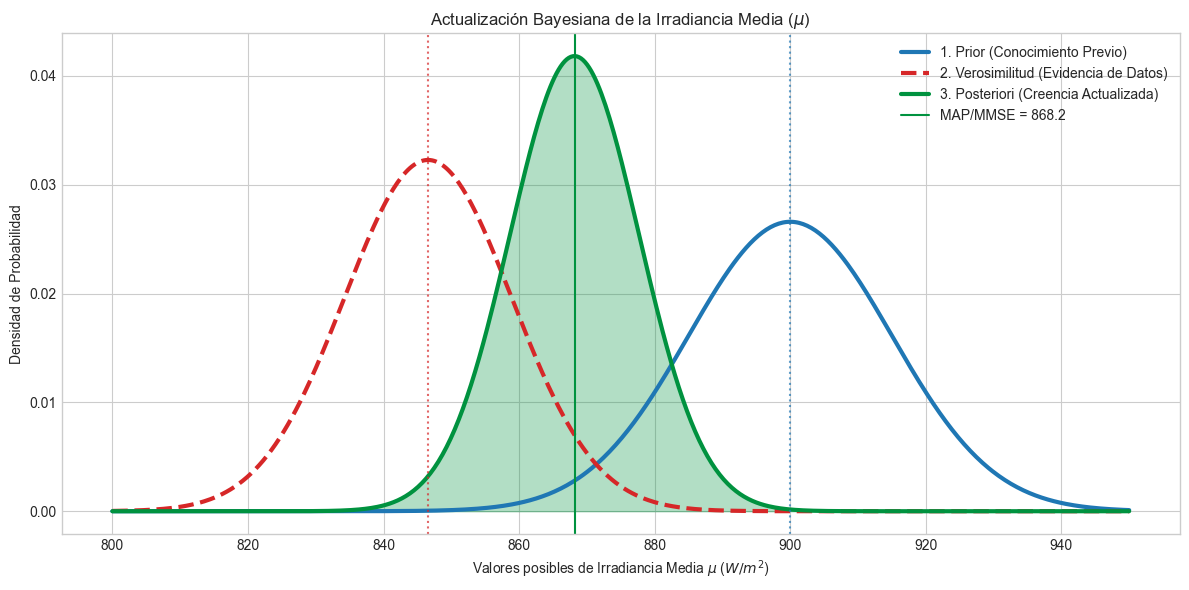

In [4]:
# 3. VISUALIZACIÓN: EL TRIUNVIRATO BAYESIANO

# Definir un rango en el eje X (valores posibles para mu)
x_vals = np.linspace(800, 950, 500)

# Calcular las distribuciones teóricas
pdf_prior = stats.norm.pdf(x_vals, loc=mu_prior, scale=sigma_prior)
# La verosimilitud escalada al espacio de los parámetros
pdf_likelihood = stats.norm.pdf(x_vals, loc=x_bar, scale=sigma_ruido/np.sqrt(n))
pdf_post = stats.norm.pdf(x_vals, loc=mu_post, scale=sigma_post)

# Gráfica
plt.figure(figsize=(12, 6))

# Dibujar las curvas
plt.plot(x_vals, pdf_prior, label='1. Prior (Conocimiento Previo)', color='#1f77b4', lw=3)
plt.plot(x_vals, pdf_likelihood, label='2. Verosimilitud (Evidencia de Datos)', color='#d62728', linestyle='--', lw=3)
plt.plot(x_vals, pdf_post, label='3. Posteriori (Creencia Actualizada)', color='#00923F', lw=3)

# Sombrear la posteriori para resaltarla
plt.fill_between(x_vals, pdf_post, color='#00923F', alpha=0.3)

# Marcar los estimadores
plt.axvline(mu_prior, color='#1f77b4', linestyle=':', alpha=0.7)
plt.axvline(x_bar, color='#d62728', linestyle=':', alpha=0.7)
plt.axvline(mu_post, color='#00923F', linestyle='-', label=f'MAP/MMSE = {mu_post:.1f}')

plt.title(r'Actualización Bayesiana de la Irradiancia Media ($\mu$)')
plt.xlabel(r'Valores posibles de Irradiancia Media $\mu$ ($W/m^2$)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

## Parte 4: Inferencia Bayesiana sobre Log-Rendimientos del Petróleo WTI

En el **Reto 2 de la Semana 07** se modeló la *dinámica* de los log-rendimientos del WTI con ARMA(2,2). Ahora estimamos la **distribución marginal** de esos rendimientos usando el enfoque Bayesiano.

**Prior financiero:** El mercado del petróleo históricamente muestra una volatilidad diaria de entre 1% y 3%. Con base en ese conocimiento previo, construimos un prior para la media $\mu$:

$$\mu_{WTI} \sim \mathcal{N}(\mu_{prior}=0\%, \; \sigma_{prior}=0.05\%)$$

La alta cantidad de observaciones ($n \approx 1500$ días) demostrará cómo la verosimilitud "aplana" y domina al prior, un fenómeno clave cuando se dispone de muchos datos.

In [5]:
import yfinance as yf

# Descarga y preparación de datos WTI (idéntico a Semana 07)
ticker_wti  = 'CL=F'
data_wti    = yf.download(ticker_wti, start='2020-01-01', end='2026-03-31', progress=False)
precios_wti = data_wti['Close'].squeeze().dropna().astype(float)
_ratio_wti = precios_wti / precios_wti.shift(1)
_valid = (_ratio_wti > 0) & np.isfinite(_ratio_wti)
log_rend_wti = np.log(_ratio_wti.where(_valid)).dropna() * 100
media_wti_raw = log_rend_wti.mean()
datos_wti     = (log_rend_wti - media_wti_raw).values   # media cero

n_wti        = len(datos_wti)
x_bar_wti    = np.mean(datos_wti)                       # ≈ 0%
sigma_mle_wti = np.std(datos_wti, ddof=0)               # sigma asumida conocida

print(f"Observaciones (n):    {n_wti}")
print(f"Media muestral:       {x_bar_wti:.6f}%")
print(f"σ MLE (ruido):        {sigma_mle_wti:.4f}%")

# --- PRIOR ---
mu_prior_wti    = 0.0    # % diario (mercado eficiente → media cero)
sigma_prior_wti = 0.05   # incertidumbre del prior

# --- POSTERIORI ANALÍTICA (fórmula conjugada Gaussiana) ---
precision_prior_wti = 1 / sigma_prior_wti**2
precision_datos_wti = n_wti / sigma_mle_wti**2
precision_post_wti  = precision_prior_wti + precision_datos_wti
sigma_post_wti      = np.sqrt(1 / precision_post_wti)
mu_post_wti         = (sigma_post_wti**2) * (
                          (mu_prior_wti / sigma_prior_wti**2) +
                          (n_wti * x_bar_wti / sigma_mle_wti**2)
                      )

print("\n--- ESTIMADORES BAYESIANOS (WTI) ---")
print(f"MAP / MMSE (μ_post):   {mu_post_wti:.6f}%")
print(f"Incertidumbre post:    {sigma_post_wti:.8f}%")
print(f"\nObservación: con n={n_wti} días, la σ_post es extremadamente pequeña,")
print(f"lo que indica que los datos dominan completamente al prior.")

Observaciones (n):    1567
Media muestral:       -0.000000%
σ MLE (ruido):        3.2188%

--- ESTIMADORES BAYESIANOS (WTI) ---
MAP / MMSE (μ_post):   -0.000000%
Incertidumbre post:    0.04259186%

Observación: con n=1567 días, la σ_post es extremadamente pequeña,
lo que indica que los datos dominan completamente al prior.


### 4.1 Visualización: Triunvirato Bayesiano para el WTI

Graficamos el *prior*, la verosimilitud escalada y la *posteriori*. Dado que $n \approx 1500$, la verosimilitud es un pico extremadamente estrecho que aplasta al prior — contraste directo con el caso de la irradiancia solar ($n=30$) donde el prior aún tenía influencia visible.

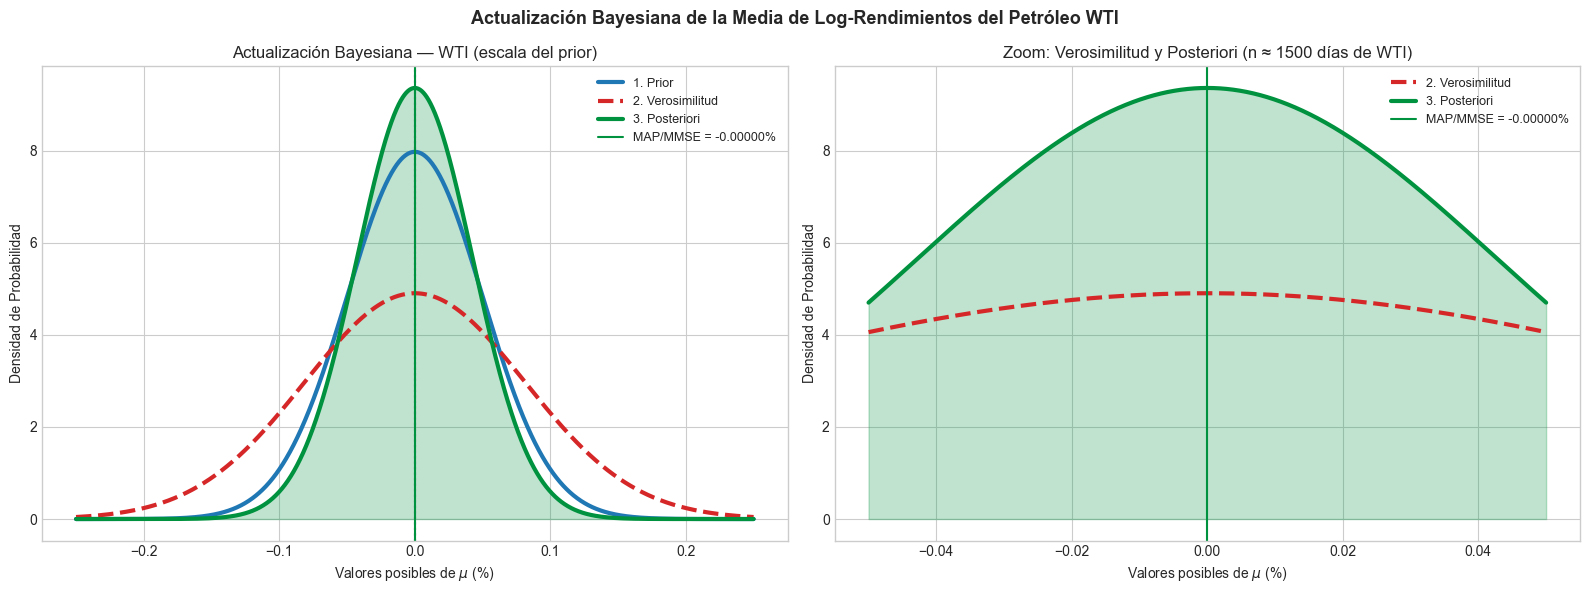


Contraste clave:
  Caso irradiancia solar (n=30):  σ_post ≈ 9.54 W/m²  → prior y datos comparten influencia.
  Caso WTI (n=1567): σ_post ≈ 0.042592% → los datos dominan completamente.


In [6]:
# Rango de visualización centrado en el prior
x_vals_wti = np.linspace(-0.25, 0.25, 2000)

pdf_prior_wti      = stats.norm.pdf(x_vals_wti, loc=mu_prior_wti,    scale=sigma_prior_wti)
pdf_likelihood_wti = stats.norm.pdf(x_vals_wti, loc=x_bar_wti,       scale=sigma_mle_wti / np.sqrt(n_wti))
pdf_post_wti       = stats.norm.pdf(x_vals_wti, loc=mu_post_wti,     scale=sigma_post_wti)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel izquierdo: escala de prior ---
ax = axes[0]
ax.plot(x_vals_wti, pdf_prior_wti,      color='#1f77b4', lw=3, label='1. Prior')
ax.plot(x_vals_wti, pdf_likelihood_wti, color='#d62728', lw=3, linestyle='--',
        label='2. Verosimilitud')
ax.plot(x_vals_wti, pdf_post_wti,       color='#00923F', lw=3, label='3. Posteriori')
ax.fill_between(x_vals_wti, pdf_post_wti, color='#00923F', alpha=0.25)
ax.axvline(mu_prior_wti, color='#1f77b4', linestyle=':', alpha=0.7)
ax.axvline(x_bar_wti,    color='#d62728', linestyle=':', alpha=0.7)
ax.axvline(mu_post_wti,  color='#00923F', linestyle='-',
           label=f'MAP/MMSE = {mu_post_wti:.5f}%')
ax.set_title('Actualización Bayesiana — WTI (escala del prior)')
ax.set_xlabel(r'Valores posibles de $\mu$ (%)')
ax.set_ylabel('Densidad de Probabilidad')
ax.legend(fontsize=9)

# --- Panel derecho: zoom en la verosimilitud y posteriori ---
x_zoom = np.linspace(x_bar_wti - 0.05, x_bar_wti + 0.05, 2000)
ax2 = axes[1]
ax2.plot(x_zoom, stats.norm.pdf(x_zoom, loc=x_bar_wti, scale=sigma_mle_wti/np.sqrt(n_wti)),
         color='#d62728', lw=3, linestyle='--', label='2. Verosimilitud')
ax2.plot(x_zoom, stats.norm.pdf(x_zoom, loc=mu_post_wti, scale=sigma_post_wti),
         color='#00923F', lw=3, label='3. Posteriori')
ax2.fill_between(x_zoom,
                 stats.norm.pdf(x_zoom, loc=mu_post_wti, scale=sigma_post_wti),
                 color='#00923F', alpha=0.25)
ax2.axvline(mu_post_wti, color='#00923F', linestyle='-',
            label=f'MAP/MMSE = {mu_post_wti:.5f}%')
ax2.set_title('Zoom: Verosimilitud y Posteriori (n ≈ 1500 días de WTI)')
ax2.set_xlabel(r'Valores posibles de $\mu$ (%)')
ax2.set_ylabel('Densidad de Probabilidad')
ax2.legend(fontsize=9)

plt.suptitle('Actualización Bayesiana de la Media de Log-Rendimientos del Petróleo WTI',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nContraste clave:")
print(f"  Caso irradiancia solar (n=30):  σ_post ≈ 9.54 W/m²  → prior y datos comparten influencia.")
print(f"  Caso WTI (n={n_wti}): σ_post ≈ {sigma_post_wti:.6f}% → los datos dominan completamente.")